# IMPORTS

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from diive.core.io.files import save_parquet, load_parquet
from diive.core.times.times import TimestampSanitizer

# LOAD DATA

## MDS versions

In [2]:
SOURCEDIR = r"../../50_REDDYPROC"
FILENAME = r"51.1_UstarThresholds_MDS-gapfilled_NEE-partitioned.csv"
FILEPATH = Path(SOURCEDIR) / FILENAME
mds = pd.read_csv(FILEPATH)

# Convert timestamp to datetime and change from end to middle
mds['TIMESTAMP_MIDDLE'] = pd.to_datetime(mds['TIMESTAMP_END'], format='%Y-%m-%dT%H:%M:%SZ', errors='coerce') - pd.Timedelta(minutes=15)
# Drop the timestamp end
mds.drop(columns='TIMESTAMP_END', inplace=True)
# Set the timestamp as index
mds.set_index('TIMESTAMP_MIDDLE', inplace=True)

# Rename for consistent naming with XGBoost versions
renaming_dict = {
    'NEE_U16_f': 'NEE_L3.3_CUT_16_QCF_footprint_gfMDS',
    'NEE_U50_f': 'NEE_L3.3_CUT_50_QCF_footprint_gfMDS',
    'NEE_U84_f': 'NEE_L3.3_CUT_84_QCF_footprint_gfMDS',
    'Reco_U16': 'RECO_NT_CUT_16_QCF_footprint_gfMDS',
    'Reco_U50': 'RECO_NT_CUT_50_QCF_footprint_gfMDS',
    'Reco_U84': 'RECO_NT_CUT_84_QCF_footprint_gfMDS',
    'GPP_U16_f': 'GPP_NT_CUT_16_QCF_footprint_gfMDS',
    'GPP_U50_f': 'GPP_NT_CUT_50_QCF_footprint_gfMDS',
    'GPP_U84_f': 'GPP_NT_CUT_84_QCF_footprint_gfMDS',
    'LE_f': 'LE_L3.2_QCF_footprint_gfMDS',
    'H_f': 'H_L3.2_QCF_footprint_gfMDS'
}
mds.rename(columns=renaming_dict, inplace=True)

# Drop thresholds
mds = mds[[c for c in renaming_dict.values()]].copy()

mds

,NEE_L3.3_CUT_16_QCF_footprint_gfMDS,NEE_L3.3_CUT_50_QCF_footprint_gfMDS,NEE_L3.3_CUT_84_QCF_footprint_gfMDS,RECO_NT_CUT_16_QCF_footprint_gfMDS,RECO_NT_CUT_50_QCF_footprint_gfMDS,RECO_NT_CUT_84_QCF_footprint_gfMDS,GPP_NT_CUT_16_QCF_footprint_gfMDS,GPP_NT_CUT_50_QCF_footprint_gfMDS,GPP_NT_CUT_84_QCF_footprint_gfMDS,LE_L3.2_QCF_footprint_gfMDS,H_L3.2_QCF_footprint_gfMDS
TIMESTAMP_MIDDLE,,,,,,,,,,,
2024-08-21 23:15:00,7.166650,7.316753,5.539503,4.627190,4.641702,4.476217,-2.539460,-2.675051,-1.063286,0.130782,-2.544480
2024-08-21 23:45:00,7.851916,8.280476,5.539503,4.579139,4.594629,4.430148,-3.272777,-3.685848,-1.109354,0.130782,-4.141530
2024-08-22 00:15:00,7.377212,7.782700,5.539503,4.547623,4.563747,4.399930,-2.829589,-3.218953,-1.139573,0.130782,-2.736035
2024-08-22 00:45:00,6.566236,5.709873,5.539503,4.512738,4.529559,4.366479,-2.053498,-1.180314,-1.173024,0.130782,-5.213054
2024-08-22 01:15:00,7.377212,7.782700,5.539503,4.533252,4.549663,4.386149,-2.843961,-3.233037,-1.153353,0.130782,-2.736035
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 20:45:00,10.578562,10.578562,10.578562,8.664950,9.318267,9.175461,-1.913612,-1.260295,-1.403101,2.365148,-37.795644
2025-06-04 21:15:00,9.416519,9.416519,9.416519,8.606190,9.256558,9.113794,-0.810329,-0.159961,-0.302725,3.145603,-33.579604
2025-06-04 21:45:00,10.095010,10.095010,10.095010,8.653859,9.306620,9.163821,-1.441151,-0.788390,-0.931189,3.778325,-38.997547


## XGBoost versions

### Gap-filling results

In [3]:
gapfilled_df = load_parquet(Path("81.4.1_NEE_GF-XGBoost.parquet"))
gapfilled_df

Loaded .parquet file 81.4.1_NEE_GF-XGBoost.parquet (0.248 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_16_QCF_parcelA,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens05,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens06,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens07,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens08,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens09,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens10,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens11,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens12,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens13,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens14,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens15,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens16,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens17,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens18,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens19
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,NaN,4.248613,4.248613,1,1.348340,1.242112,0.524575,1.348340,1.468070,5.632235,5.166770,5.441307,5.288424,5.399285,5.219240,...,5.669019,5.061279,6.697467,5.114174,4.611203,5.479743,5.578880,5.127724,5.486167,5.406295,5.441463,5.134264,5.207870,4.458621,5.355805
2024-08-22 00:45:00,NaN,4.248613,4.248613,1,1.341988,1.242112,0.508025,1.341988,3.661990,5.632235,5.166770,5.441307,5.288424,5.375426,5.267838,...,5.493054,4.800270,6.614696,4.984047,4.542683,5.458522,5.522336,4.906122,5.534100,5.443357,5.440093,5.309669,5.001252,4.531747,5.374063
2024-08-22 01:15:00,NaN,4.248613,4.248613,1,1.341339,1.242112,0.506309,1.341339,0.965964,5.632235,5.196208,5.463774,5.265171,5.375426,5.208541,...,5.669019,4.958463,6.455025,5.114174,4.611203,5.399852,5.578880,5.164246,5.453488,5.338524,5.441463,5.134264,5.207870,4.527202,5.366464
2024-08-22 01:45:00,6.566236,4.119246,6.566236,0,1.336125,1.242112,0.492329,1.585380,1.585380,5.632235,5.196208,5.455657,5.265171,5.375426,5.239306,...,5.493054,4.840718,6.395240,4.977121,4.542683,5.350466,5.522336,4.919437,5.501421,5.336229,5.611243,5.309669,5.051096,4.600329,5.325774
2024-08-22 02:15:00,NaN,4.119246,4.119246,1,1.349985,1.242112,0.528788,1.349985,1.852140,5.586957,5.106067,5.472393,5.039294,5.281761,5.093706,...,5.493054,4.868279,6.367209,4.913272,4.542683,5.299899,5.490047,4.905828,5.352509,5.323313,5.485988,5.245954,5.044921,4.641542,5.325774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,NaN,9.784657,9.784657,1,1.728474,1.706768,0.273068,1.728474,0.510651,9.773724,9.897761,10.117984,9.943034,10.050313,9.901470,...,10.291671,10.313585,10.184143,10.205165,10.130551,10.295714,10.356476,10.397308,10.342398,10.320307,10.193606,10.241170,10.258471,9.518491,10.381469
2025-06-04 22:15:00,NaN,9.631040,9.631040,1,1.720498,1.706768,0.216928,1.720498,0.432552,9.595117,9.716796,9.686436,9.779700,9.861654,9.733327,...,9.966759,10.049745,9.811559,9.947085,9.834920,9.990389,10.353203,10.252034,10.062006,9.955725,10.081480,10.062689,10.042943,9.379811,9.890552
2025-06-04 22:45:00,NaN,9.684240,9.684240,1,1.722199,1.706768,0.230031,1.722199,0.580992,9.497993,9.716247,9.609970,9.804771,9.784874,9.708615,...,10.002312,9.968057,9.775000,9.895196,9.955281,9.883547,10.131139,10.174637,9.933991,10.046745,10.068542,10.189172,9.957444,9.379811,10.019363


### Partitioning results

In [4]:
part_path = "81.5.1_NEE_XG-GAPF_PART_ReddyProc.csv"
part_df = pd.read_csv(part_path)
part_df = part_df.set_index("TIMESTAMP")
part_df.index.name = "TIMESTAMP_END"
part_df = TimestampSanitizer(data=part_df).get()
part_df

,Tair_orig,Tair_f,Tair_fqc,Tair_fall,Tair_fall_qc,Tair_fnum,Tair_fsd,Tair_fmeth,Tair_fwin,Rg_orig,Rg_f,Rg_fqc,Rg_fall,Rg_fall_qc,Rg_fnum,...,FP_GPP2000,FP_k,FP_beta,FP_alpha,FP_RRef,FP_E0,FP_k_sd,FP_beta_sd,FP_alpha_sd,FP_RRef_sd,FP_E0_sd,Reco_DT_QCF0,GPP_DT_QCF0,Reco_DT_QCF0_SD,GPP_DT_QCF0_SD
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,11.276667,11.276667,0,11.276667,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.160040,0.0,0.554113,0.0
2024-08-22 00:45:00,11.043333,11.043333,0,11.043333,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.130922,0.0,0.556215,0.0
2024-08-22 01:15:00,10.890000,10.890000,0,10.890000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.111770,0.0,0.557604,0.0
2024-08-22 01:45:00,10.720000,10.720000,0,10.720000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.090520,0.0,0.559150,0.0
2024-08-22 02:15:00,10.820000,10.820000,0,10.820000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.103022,0.0,0.558240,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,15.693333,15.693333,0,15.693333,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.649592,0.0,0.416887,0.0
2025-06-04 22:15:00,15.516667,15.516667,0,15.516667,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.583412,0.0,0.415820,0.0
2025-06-04 22:45:00,15.660000,15.660000,0,15.660000,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.637100,0.0,0.416595,0.0


# CLEAN PARTITIONING RESULTS

## Identify GPP and RECO columns

In [5]:
partcols = [c for c in part_df.columns if any(substring in c for substring in ["GPP", "Reco"])];
partcols = [c for c in partcols if not str(c).endswith("_fqc") and not str(c).endswith("_SD") and '_DT' not in c] 
partcols.remove("FP_GPP2000")
partcols

['Reco_QCF', 'GPP_QCF_f', 'Reco_QCF0', 'GPP_QCF0_f']

## Create subset with GPP and RECO columns

In [6]:
subset_partcols = part_df[partcols].copy()
subset_partcols

,Reco_QCF,GPP_QCF_f,Reco_QCF0,GPP_QCF0_f
TIMESTAMP_MIDDLE,,,,
2024-08-22 00:15:00,5.266725,0.475098,5.257461,0.465834
2024-08-22 00:45:00,5.228559,0.662601,5.218945,0.652987
2024-08-22 01:15:00,5.203461,0.530312,5.193618,0.520470
2024-08-22 01:45:00,5.175618,0.851883,5.165524,0.841788
2024-08-22 02:15:00,5.191998,0.868263,5.182052,0.858317
...,...,...,...,...
2025-06-04 21:45:00,9.608364,-0.970199,9.608842,-0.969720
2025-06-04 22:15:00,9.562919,0.146401,9.562897,0.146379
2025-06-04 22:45:00,9.599793,-0.495217,9.600177,-0.494833


## Rename partitioning variables

In [7]:
renaming_dict = {
    # Nighttime paritioning results for parcels A and B
    'GPP_QCF_f': 'GPP_NT_CUT_50_QCF_footprint_gfXGBoost', 
    'GPP_QCF0_f': 'GPP_NT_CUT_50_QCF0_footprint_gfXGBoost',
    'Reco_QCF': 'RECO_NT_CUT_50_QCF_footprint_gfXGBoost',
    'Reco_QCF0': 'RECO_NT_CUT_50_QCF0_footprint_gfXGBoost'
}

subset_partcols = subset_partcols.rename(columns=renaming_dict, inplace=False)
subset_partcols

,RECO_NT_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,RECO_NT_CUT_50_QCF0_footprint_gfXGBoost,GPP_NT_CUT_50_QCF0_footprint_gfXGBoost
TIMESTAMP_MIDDLE,,,,
2024-08-22 00:15:00,5.266725,0.475098,5.257461,0.465834
2024-08-22 00:45:00,5.228559,0.662601,5.218945,0.652987
2024-08-22 01:15:00,5.203461,0.530312,5.193618,0.520470
2024-08-22 01:45:00,5.175618,0.851883,5.165524,0.841788
2024-08-22 02:15:00,5.191998,0.868263,5.182052,0.858317
...,...,...,...,...
2025-06-04 21:45:00,9.608364,-0.970199,9.608842,-0.969720
2025-06-04 22:15:00,9.562919,0.146401,9.562897,0.146379
2025-06-04 22:45:00,9.599793,-0.495217,9.600177,-0.494833


# MERGE

In [8]:
df = pd.concat([gapfilled_df, subset_partcols, mds], axis=1)
df

,NEE_L3.3_CUT_16_QCF_parcelA,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,RECO_NT_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,RECO_NT_CUT_50_QCF0_footprint_gfXGBoost,GPP_NT_CUT_50_QCF0_footprint_gfXGBoost,NEE_L3.3_CUT_16_QCF_footprint_gfMDS,NEE_L3.3_CUT_50_QCF_footprint_gfMDS,NEE_L3.3_CUT_84_QCF_footprint_gfMDS,RECO_NT_CUT_16_QCF_footprint_gfMDS,RECO_NT_CUT_50_QCF_footprint_gfMDS,RECO_NT_CUT_84_QCF_footprint_gfMDS,GPP_NT_CUT_16_QCF_footprint_gfMDS,GPP_NT_CUT_50_QCF_footprint_gfMDS,GPP_NT_CUT_84_QCF_footprint_gfMDS,LE_L3.2_QCF_footprint_gfMDS,H_L3.2_QCF_footprint_gfMDS
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-21 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.166650,7.316753,5.539503,4.627190,4.641702,4.476217,-2.539460,-2.675051,-1.063286,0.130782,-2.544480
2024-08-21 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.851916,8.280476,5.539503,4.579139,4.594629,4.430148,-3.272777,-3.685848,-1.109354,0.130782,-4.141530
2024-08-22 00:15:00,NaN,4.248613,4.248613,1.0,1.348340,1.242112,0.524575,1.348340,1.468070,5.632235,5.166770,5.441307,5.288424,5.399285,5.219240,...,5.266725,0.475098,5.257461,0.465834,7.377212,7.782700,5.539503,4.547623,4.563747,4.399930,-2.829589,-3.218953,-1.139573,0.130782,-2.736035
2024-08-22 00:45:00,NaN,4.248613,4.248613,1.0,1.341988,1.242112,0.508025,1.341988,3.661990,5.632235,5.166770,5.441307,5.288424,5.375426,5.267838,...,5.228559,0.662601,5.218945,0.652987,6.566236,5.709873,5.539503,4.512738,4.529559,4.366479,-2.053498,-1.180314,-1.173024,0.130782,-5.213054
2024-08-22 01:15:00,NaN,4.248613,4.248613,1.0,1.341339,1.242112,0.506309,1.341339,0.965964,5.632235,5.196208,5.463774,5.265171,5.375426,5.208541,...,5.203461,0.530312,5.193618,0.520470,7.377212,7.782700,5.539503,4.533252,4.549663,4.386149,-2.843961,-3.233037,-1.153353,0.130782,-2.736035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,NaN,9.784657,9.784657,1.0,1.728474,1.706768,0.273068,1.728474,0.510651,9.773724,9.897761,10.117984,9.943034,10.050313,9.901470,...,9.608364,-0.970199,9.608842,-0.969720,10.095010,10.095010,10.095010,8.653859,9.306620,9.163821,-1.441151,-0.788390,-0.931189,3.778325,-38.997547
2025-06-04 22:15:00,NaN,9.631040,9.631040,1.0,1.720498,1.706768,0.216928,1.720498,0.432552,9.595117,9.716796,9.686436,9.779700,9.861654,9.733327,...,9.562919,0.146401,9.562897,0.146379,8.641342,8.641342,8.641342,8.637225,9.289152,9.146365,-0.004116,0.647810,0.505023,-0.947239,-39.849475
2025-06-04 22:45:00,NaN,9.684240,9.684240,1.0,1.722199,1.706768,0.230031,1.722199,0.580992,9.497993,9.716247,9.609970,9.804771,9.784874,9.708615,...,9.599793,-0.495217,9.600177,-0.494833,8.664543,8.664543,8.664543,8.531922,9.178548,9.035847,-0.132621,0.514005,0.371304,2.372576,-53.513862


# PLOT

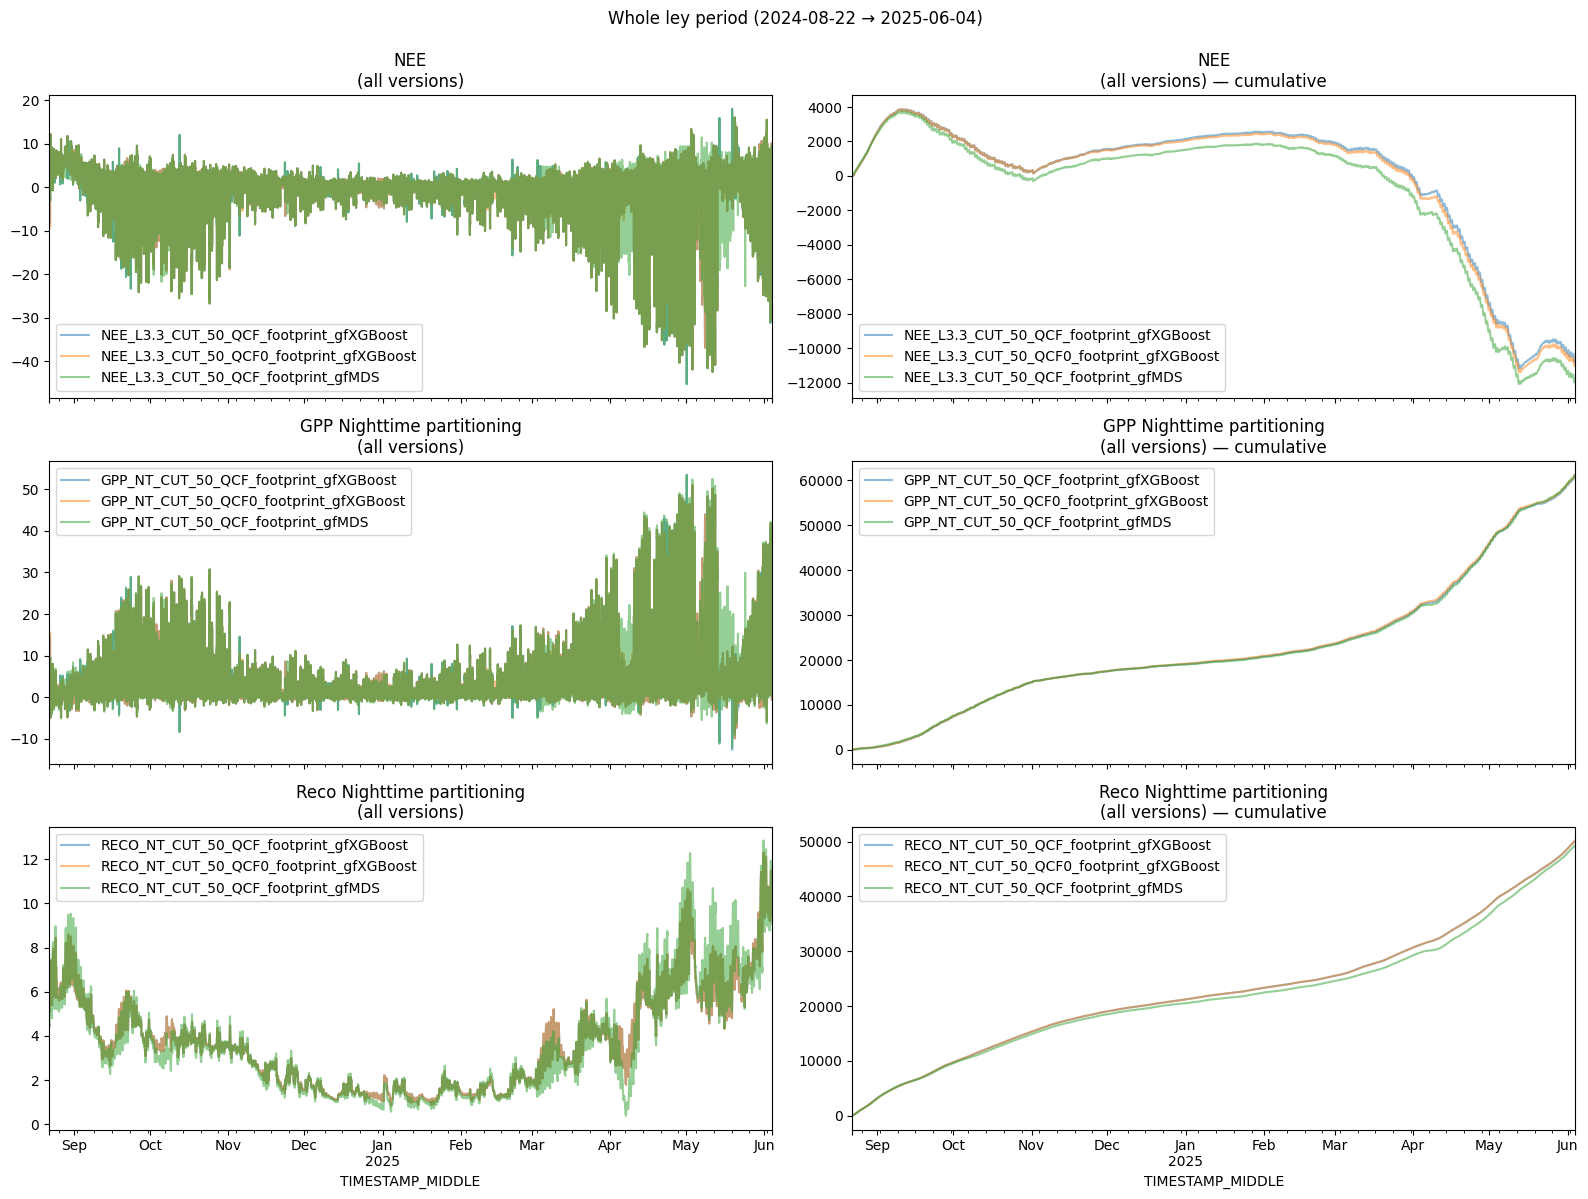

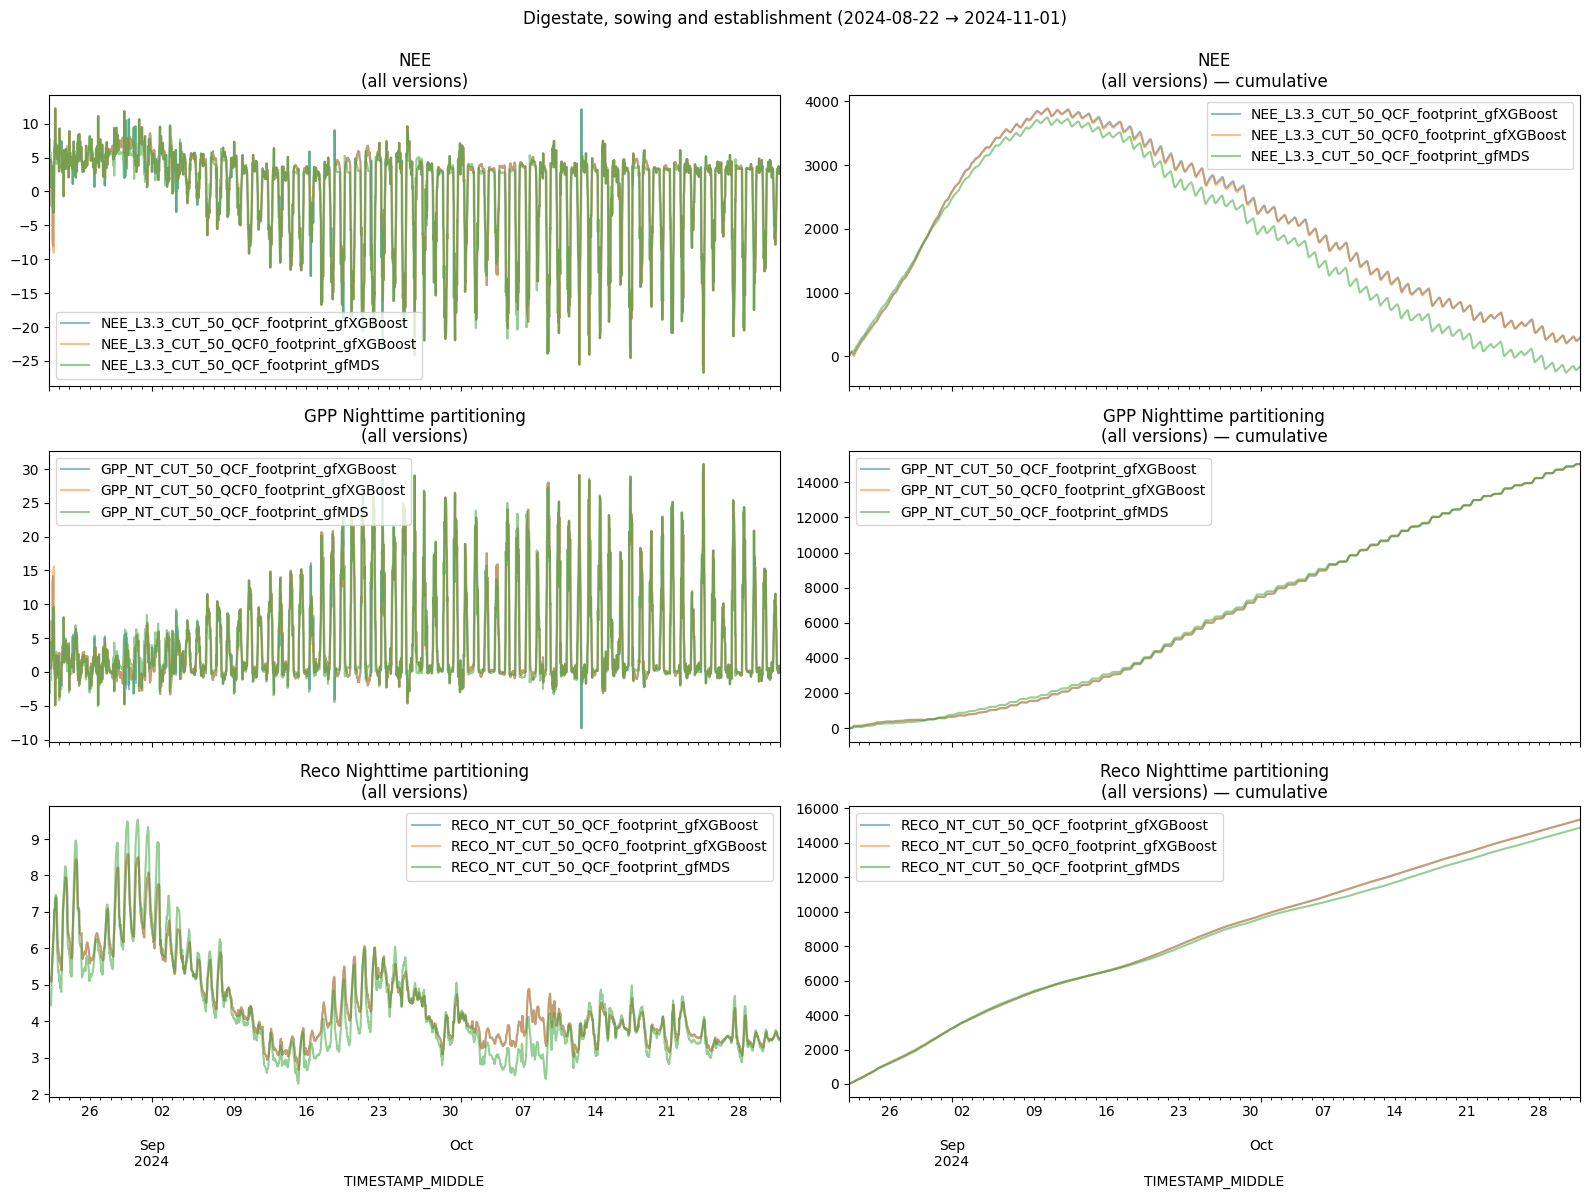

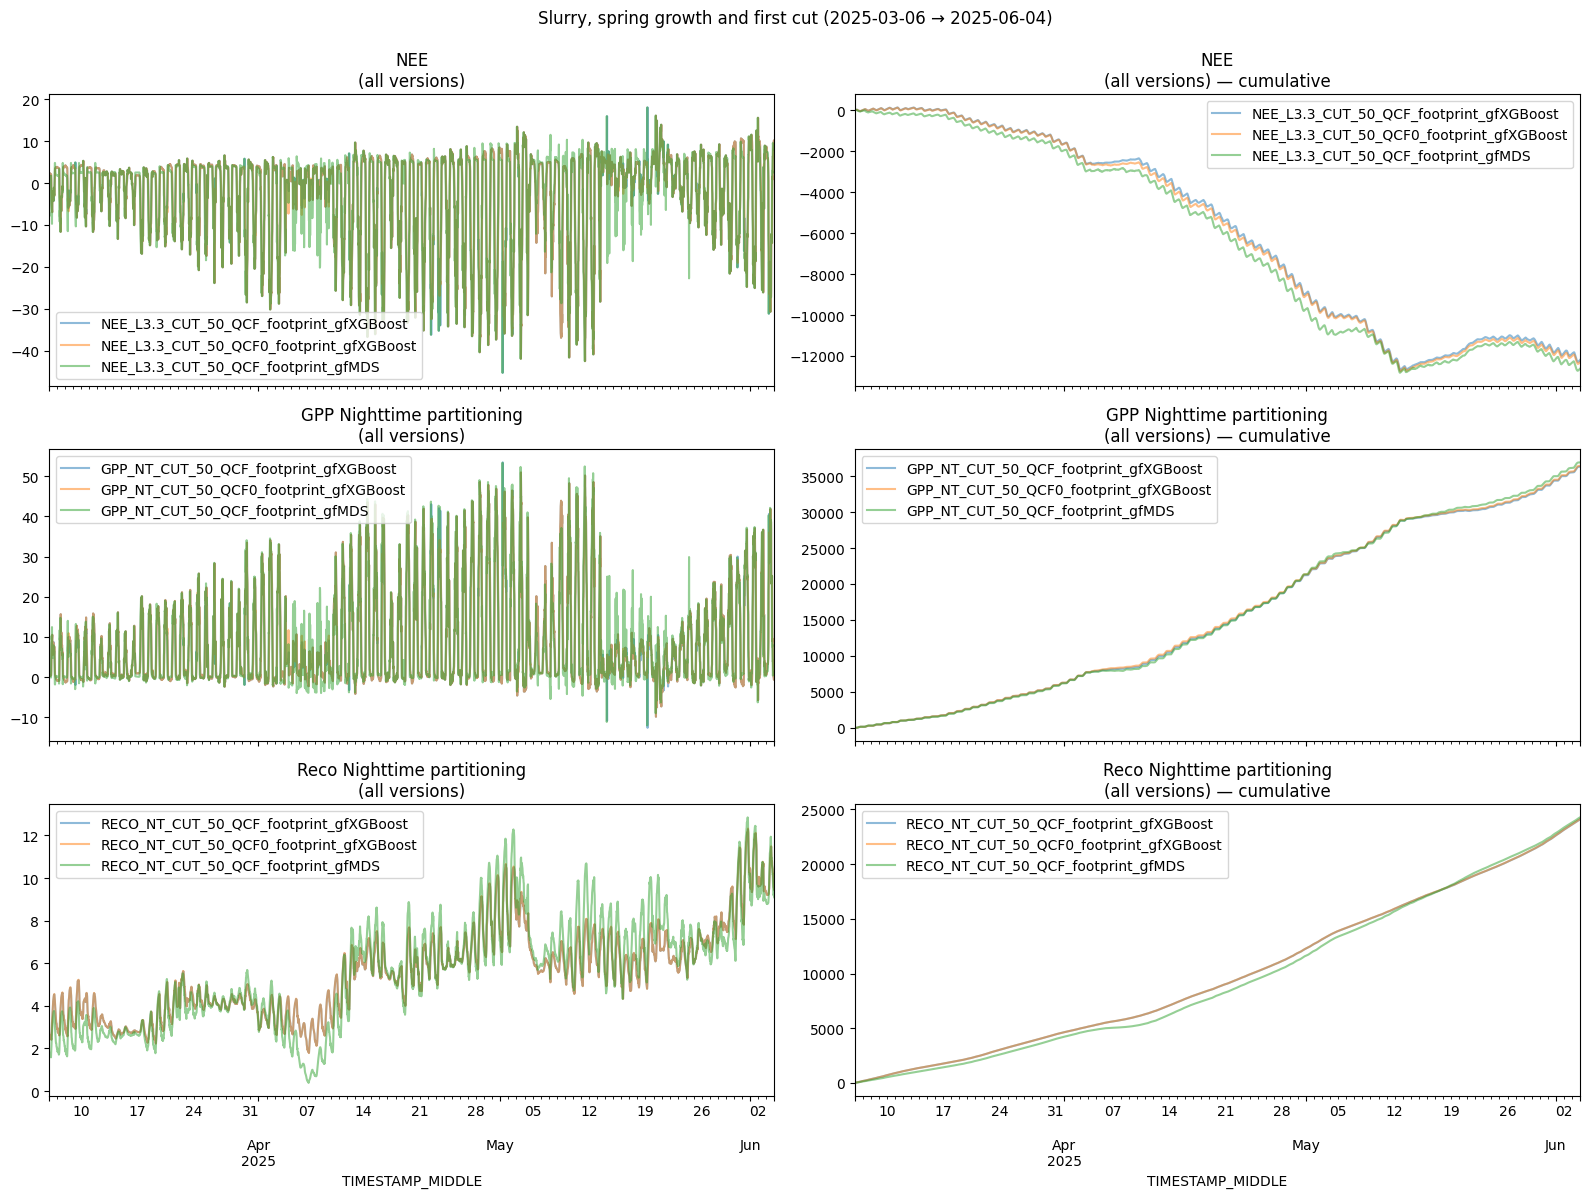

In [9]:
# Define periods
periods = [
    ("2024-08-22", "2025-06-04", "Whole ley period"),
    ("2024-08-22", "2024-11-01", "Digestate, sowing and establishment"),
    ("2025-03-06", "2025-06-04", "Slurry, spring growth and first cut"),
]

for start, end, label in periods:
    period_df = df.loc[pd.to_datetime(start):pd.to_datetime(end)]
    pairs = [
        ([c for c in df.columns if c.startswith('NEE_L3.3_CUT_50') and (c.endswith('footprint_gfXGBoost') or c.endswith('footprint_gfMDS'))], "NEE\n(all versions)"),       
        ([c for c in df.columns if c.startswith('GPP_NT_CUT_50')], "GPP Nighttime partitioning\n(all versions)"),
        ([c for c in df.columns if c.startswith('RECO_NT_CUT_50')], "Reco Nighttime partitioning\n(all versions)"),
    ]

    # Keep only existing columns
    pairs = [(cols, t) for cols, t in pairs if all(c in period_df.columns for c in cols)]
    nrows, ncols = len(pairs), 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows), sharex='col')
    if nrows == 1:  # make indexing uniform
        axes = axes.reshape(1, ncols)

    for r, (cols, t) in enumerate(pairs):
        # raw
        period_df[cols].plot(ax=axes[r, 0], alpha=0.5)
        axes[r, 0].set_title(f"{t}")

        # cumulative
        cumulative = period_df[cols].cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.5)
        axes[r, 1].set_title(f"{t} — cumulative")

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()

# EXPORT DATA

In [10]:
filename = "81.6.1_NEE_GF-XGBoost_GPP_RECO"
save_parquet(data=df, filename=filename)

Saved file 81.6.1_NEE_GF-XGBoost_GPP_RECO.parquet (1.274 seconds).


'81.6.1_NEE_GF-XGBoost_GPP_RECO.parquet'

# End of notebook

In [11]:
from datetime import datetime
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-10-07 14:22:41
